# Comparative Evaluation: Greedy_SOSP vs Robust_MOSP vs Dijkstra

This notebook benchmarks `Greedy_SOSP`, `Robust_MOSP`, and a baseline Dijkstra implementation across varying graph sizes and edge densities. The goal is to produce reproducible runtime and scalability results for research paper analysis.

In [1]:
import time
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D

from Greedy_SOSP import Greedy_SOSP
from Robust_MOSP import Robust_MOSP
from utils.generate_graph import generate_graph

NODE_SIZES = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
EDGE_PROBS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
REPEAT = 10

def dijkstra_baseline_runtime(G, source=None):
    if source is None:
        source = next(iter(G.nodes()))
    start = time.perf_counter()
    nx.single_source_dijkstra_path_length(G, source, weight="expected_energy")
    return time.perf_counter() - start

def run_comparison_trial(n, p, repeat_id=None):
    G = generate_graph(n, p, seed=repeat_id, with_metrics=True)
    source = next(iter(G.nodes()))

    start = time.perf_counter()
    Greedy_SOSP(G)
    greedy_time = time.perf_counter() - start

    start = time.perf_counter()
    Robust_MOSP(G)
    robust_time = time.perf_counter() - start

    dijkstra_time = dijkstra_baseline_runtime(G, source)

    return {
        "requested_nodes": n,
        "actual_nodes": G.number_of_nodes(),
        "edge_prob": p,
        "repeat": repeat_id,
        "greedy_runtime": greedy_time,
        "robust_runtime": robust_time,
        "dijkstra_runtime": dijkstra_time,
    }

In [2]:
results = []
total_runs = len(NODE_SIZES) * len(EDGE_PROBS) * REPEAT

with tqdm(total=total_runs, desc="Benchmarking") as pbar:
    for n in NODE_SIZES:
        for p in EDGE_PROBS:
            for r in range(REPEAT):
                trial = run_comparison_trial(n, p, repeat_id=r)
                results.append(trial)
                pbar.update(1)

df_comparison = pd.DataFrame(results)
df_comparison.to_csv("Greedy_Robust_Dijkstra_Comparison_results.csv", index=False)
df_comparison.head()

Benchmarking: 100%|██████████| 540/540 [32:48<00:00,  3.65s/it] 


,requested_nodes,actual_nodes,edge_prob,repeat,greedy_runtime,robust_runtime,dijkstra_runtime
0,4,1,0.1,0,0.000050,0.001697,0.000544
1,4,1,0.1,1,0.000028,0.000173,0.000023
2,4,1,0.1,2,0.000008,0.000097,0.000006
3,4,1,0.1,3,0.000007,0.000089,0.000005
4,4,1,0.1,4,0.000009,0.000089,0.000005


C:\Users\hp\AppData\Local\Temp\ipykernel_16688\3104165918.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


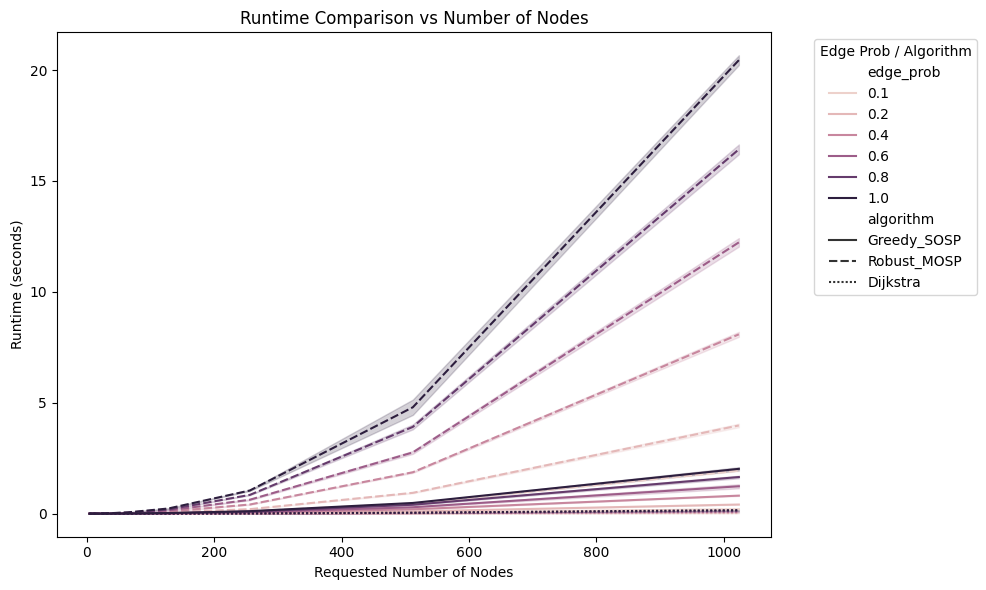

In [3]:
df = pd.read_csv("Greedy_Robust_Dijkstra_Comparison_results.csv")
df_long = df.melt(
    id_vars=["requested_nodes", "actual_nodes", "edge_prob", "repeat"],
    value_vars=["greedy_runtime", "robust_runtime", "dijkstra_runtime"],
    var_name="algorithm",
    value_name="runtime"
)
algorithm_labels = {
    "greedy_runtime": "Greedy_SOSP",
    "robust_runtime": "Robust_MOSP",
    "dijkstra_runtime": "Dijkstra",
}
df_long["algorithm"] = df_long["algorithm"].map(algorithm_labels)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_long,
    x="requested_nodes",
    y="runtime",
    hue="edge_prob",
    style="algorithm",
    estimator="mean",
    ci="sd"
)
plt.title("Runtime Comparison vs Number of Nodes")
plt.xlabel("Requested Number of Nodes")
plt.ylabel("Runtime (seconds)")
plt.legend(title="Edge Prob / Algorithm", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_16688\690432841.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


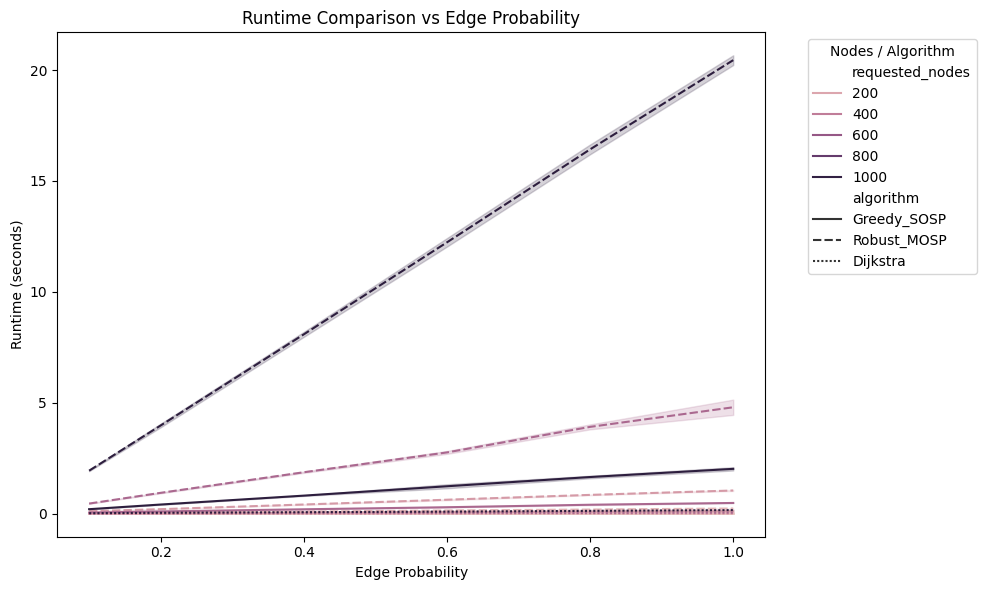

In [4]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_long,
    x="edge_prob",
    y="runtime",
    hue="requested_nodes",
    style="algorithm",
    estimator="mean",
    ci="sd"
)
plt.title("Runtime Comparison vs Edge Probability")
plt.xlabel("Edge Probability")
plt.ylabel("Runtime (seconds)")
plt.legend(title="Nodes / Algorithm", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

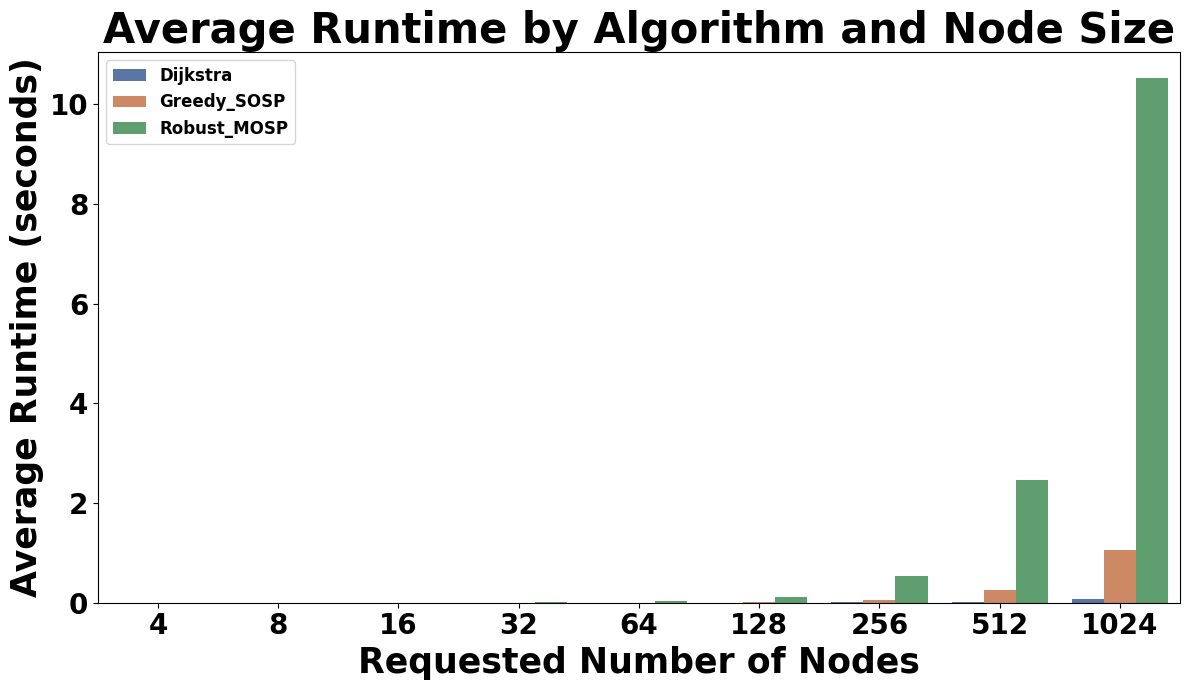

In [30]:
plt.figure(figsize=(12, 7))
summary = df_long.groupby(["requested_nodes", "algorithm"])["runtime"].mean().reset_index()
sns.barplot(
    data=summary,
    x="requested_nodes",
    y="runtime",
    hue="algorithm",
    palette="deep"
)
plt.title("Average Runtime by Algorithm and Node Size", fontsize=30, fontweight="bold")
plt.xlabel("Requested Number of Nodes", fontsize=25, fontweight = 'heavy')
plt.ylabel("Average Runtime (seconds)", fontsize=25, fontweight = 'heavy')
plt.xticks(fontsize=20, fontweight = 'heavy')
plt.yticks(fontsize=20, fontweight = 'heavy')
plt.legend(title_fontsize=13, prop={"weight": "bold", "size": 12})
plt.tight_layout()
plt.savefig("Average_Runtime_Barplot.pdf", dpi=600, bbox_inches="tight")
plt.show()

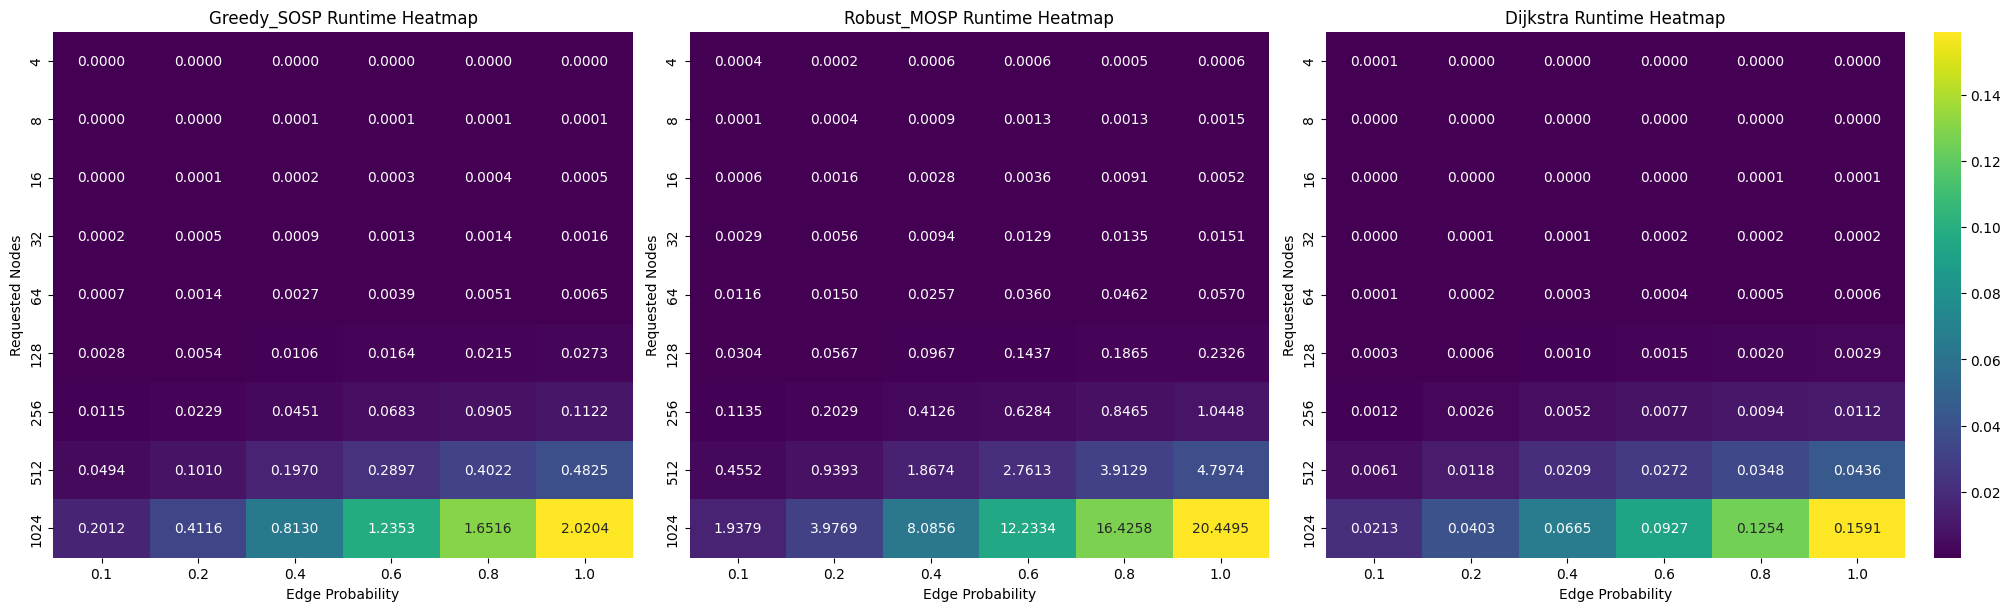

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for ax, algo, title in zip(axes, ["Greedy_SOSP", "Robust_MOSP", "Dijkstra"], ["Greedy_SOSP", "Robust_MOSP", "Dijkstra"]):
    pivot = df_long[df_long["algorithm"] == algo].pivot_table(
        values="runtime",
        index="requested_nodes",
        columns="edge_prob",
        aggfunc="mean"
    )
    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".4f",
        cmap="viridis",
        cbar= ax is axes[-1],
    )
    ax.set_title(f"{title} Runtime Heatmap")
    ax.set_xlabel("Edge Probability")
    ax.set_ylabel("Requested Nodes")
plt.show()

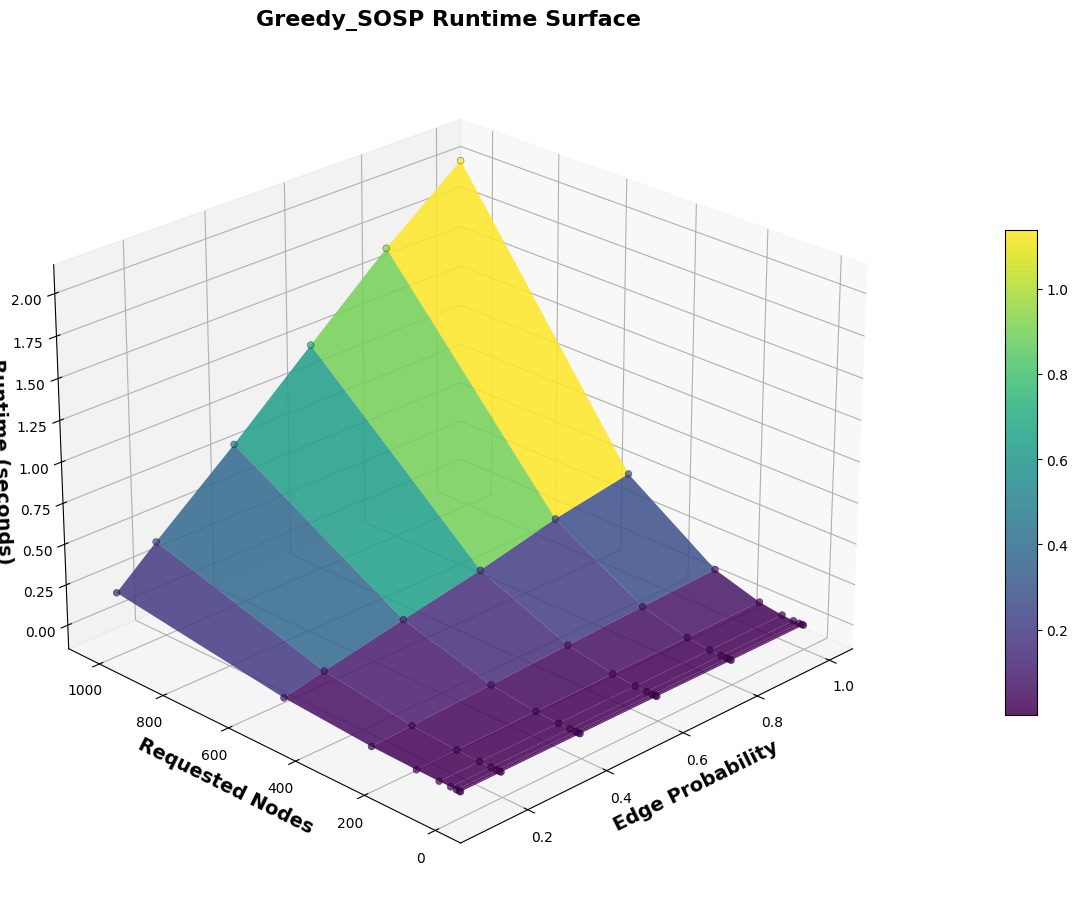

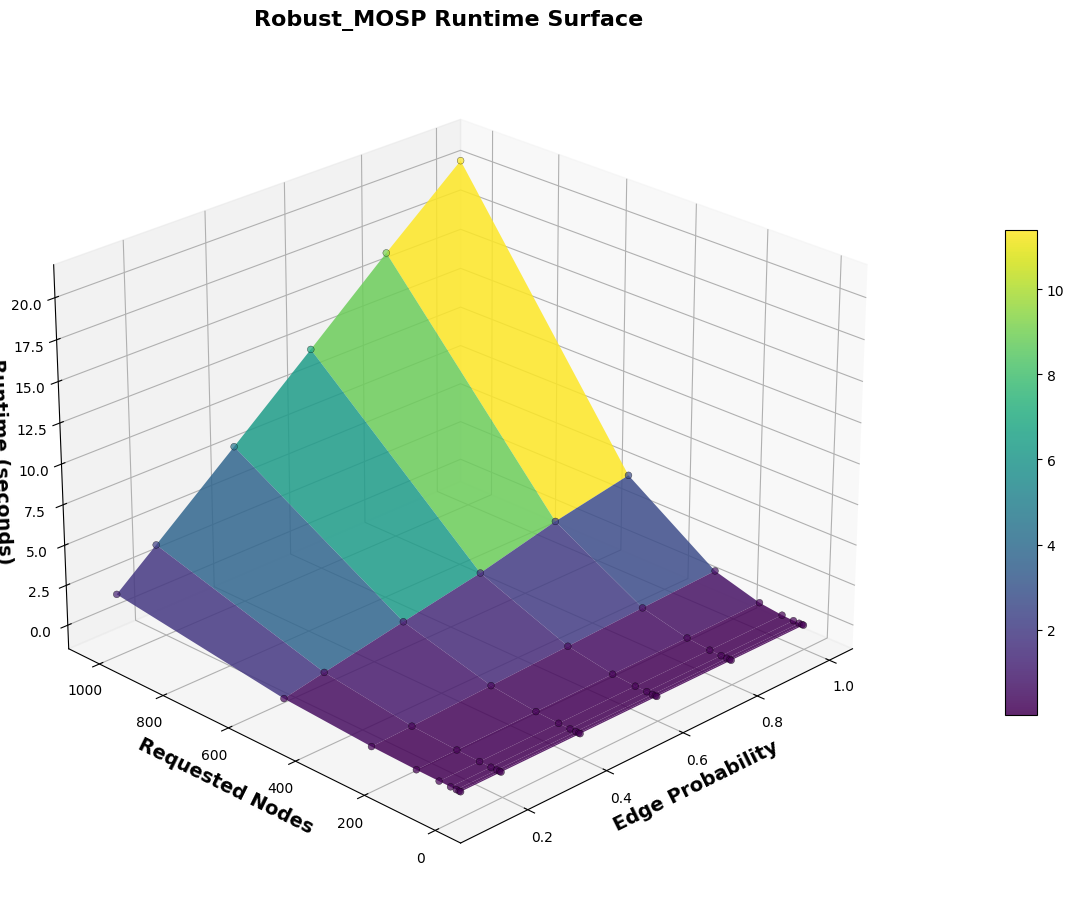

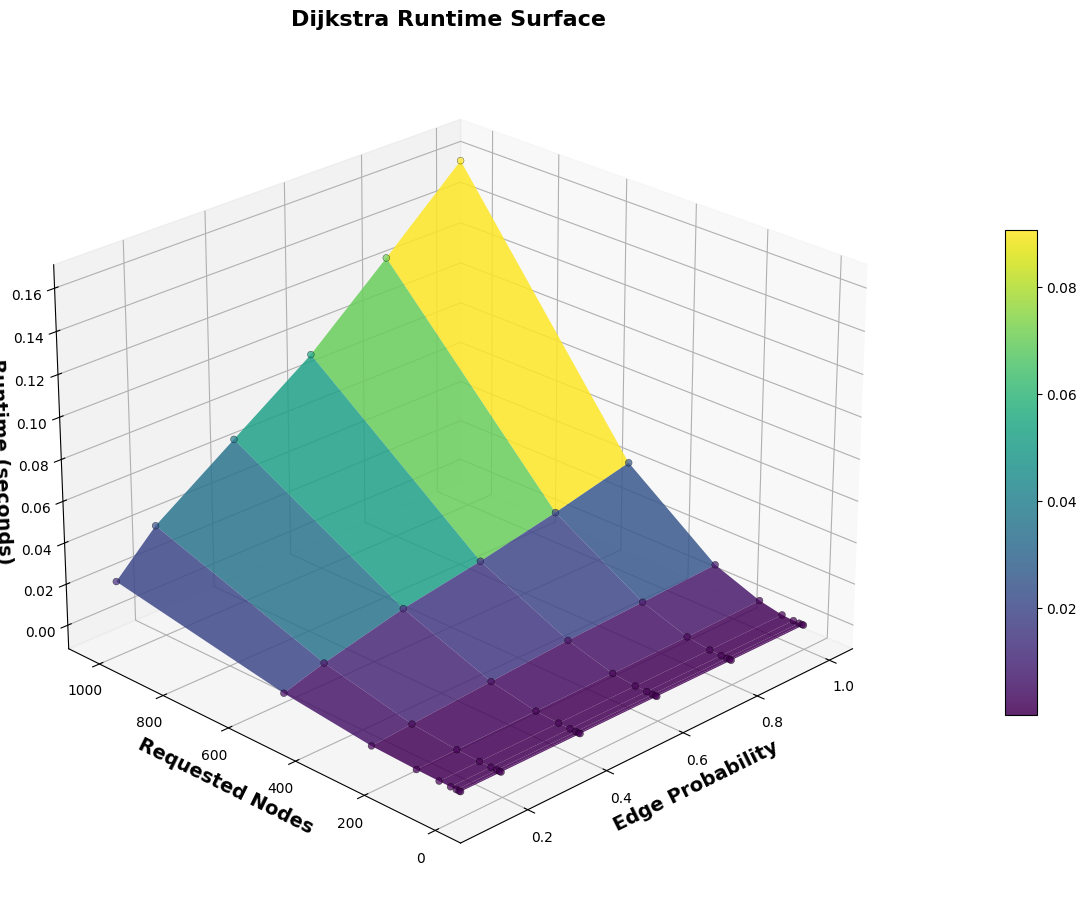

In [7]:
def plot_3d_surface(df_results, algorithm, filename=None):
    pivot = df_results.pivot_table(
        values="runtime",
        index="requested_nodes",
        columns="edge_prob",
        aggfunc="mean"
    )
    nodes = pivot.index.values
    edge_probs = pivot.columns.values
    X, Y = np.meshgrid(edge_probs, nodes)
    Z = pivot.values

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection="3d")
    surface = ax.plot_surface(
        X, Y, Z,
        cmap="viridis",
        edgecolor="none",
        alpha=0.85,
        linewidth=0,
        antialiased=True,
    )
    ax.scatter(X, Y, Z, c=Z, cmap="viridis", s=24, alpha=0.7, edgecolor="k", linewidth=0.3)
    ax.set_xlabel("Edge Probability", fontsize=14, fontweight="bold")
    ax.set_ylabel("Requested Nodes", fontsize=14, fontweight="bold")
    ax.set_zlabel("Runtime (seconds)", fontsize=14, fontweight="bold")
    ax.set_title(f"{algorithm} Runtime Surface", fontsize=16, fontweight="bold")
    ax.view_init(elev=25, azim=225)
    fig.colorbar(surface, shrink=0.5, aspect=15, pad=0.1)
    plt.tight_layout()
    if filename is not None:
        fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

for algo in ["Greedy_SOSP", "Robust_MOSP", "Dijkstra"]:
    plot_3d_surface(df_long[df_long["algorithm"] == algo], algo, filename=f"{algo}_Runtime_Surface.pdf")

In [10]:
print("=== Summary Statistics ===")

for algo in ["Greedy_SOSP", "Robust_MOSP", "Dijkstra"]:
    subset = df_long[df_long["algorithm"] == algo].copy()

    print(f"\nAlgorithm: {algo}")
    print(subset["runtime"].describe())

    print("Mean runtime by nodes:")
    print(subset.groupby("requested_nodes")["runtime"].mean())

    print("Mean runtime by edge probability:")
    print(subset.groupby("edge_prob")["runtime"].mean())

=== Summary Statistics ===

Algorithm: Greedy_SOSP
count    540.000000
mean       0.154029
std        0.397145
min        0.000006
25%        0.000133
50%        0.002726
75%        0.068830
max        2.224955
Name: runtime, dtype: float64
Mean runtime by nodes:
requested_nodes
4       0.000033
8       0.000076
16      0.000268
32      0.000973
64      0.003365
128     0.013994
256     0.058402
512     0.253622
1024    1.055528
Name: runtime, dtype: float64
Mean runtime by edge probability:
edge_prob
0.1    0.029528
0.2    0.060327
0.4    0.118842
0.6    0.179476
0.8    0.241425
1.0    0.294576
Name: runtime, dtype: float64

Algorithm: Robust_MOSP
count    540.000000
mean       1.520741
std        3.973611
min        0.000079
25%        0.001748
50%        0.029077
75%        0.618966
max       20.836432
Name: runtime, dtype: float64
Mean runtime by nodes:
requested_nodes
4        0.000487
8        0.000923
16       0.003812
32       0.009889
64       0.031914
128      0.124431
256   